In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Cleaned_Restaurant_Dataset.csv')

In [ ]:
df.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisine_Count
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,3
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,1
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,4


#**LEVEL 1**

# **TASK 1 (Task: Top Cuisines)**

**1.Determine the top three most common cuisines in the dataset.**

In [ ]:
#. Extract and count individual cuisines
all_cuisines = df['Cuisines'].str.split(', ').explode()
cuisine_counts = all_cuisines.value_counts()

In [ ]:
cuisine_counts

,count
Cuisines,
North Indian,3960
Chinese,2735
Fast Food,1986
Mughlai,995
Italian,764
...,...
Cuisine Varies,1
Fish and Chips,1
Durban,1


**Get Top 3 Cuisines**

In [ ]:
#. Get Top 3 Cuisines
top_3_cuisines = cuisine_counts.head(3)

In [ ]:
#. Print the names for top 3 Cuisines
print("Top 3 Most Common Cuisines:")
for i, name in enumerate(top_3_cuisines.index, 1):
    print(f"{i}. {name}")

Top 3 Most Common Cuisines:
1. North Indian
2. Chinese
3. Fast Food


**Visualization**

/tmp/ipykernel_595/1911898858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_3_cuisines.index, y=top_3_cuisines.values, palette='magma')


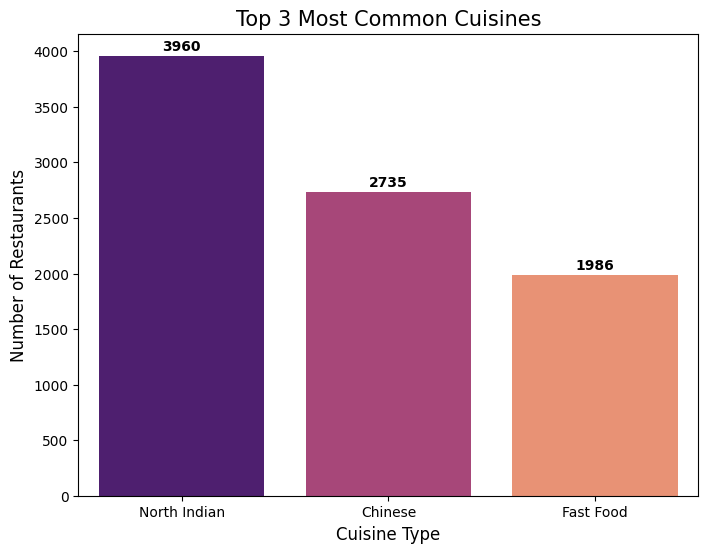

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=top_3_cuisines.index, y=top_3_cuisines.values, palette='magma')
plt.title('Top 3 Most Common Cuisines', fontsize=15)
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)

for i, value in enumerate(top_3_cuisines.values):
    plt.text(i, value + 50, str(value), ha='center', fontweight='bold')


**2.Calculate the percentage of restaurants that serve each of the top cuisines**

In [ ]:
#. Calculate the total number of restaurants in the dataset
total_restaurants = len(df)
print(f"Total Restaurants: {total_restaurants}")

Total Restaurants: 9551


In [ ]:
#. Extract and count all individual cuisines
all_cuisines = df['Cuisines'].str.split(', ').explode()
cuisine_counts = all_cuisines.value_counts()

In [ ]:
#. Filter for the Top 10
top_10_cuisines = cuisine_counts.head(10)
top_10_df = pd.DataFrame({
    'Cuisine': top_10_cuisines.index,
    'Count': top_10_cuisines.values,
    'Percentage': (top_10_cuisines.values / total_restaurants) * 100
})

In [ ]:
print("Top 10 Cuisines:")
print(top_10_df)

Top 10 Cuisines:
        Cuisine  Count  Percentage
0  North Indian   3960   41.461627
1       Chinese   2735   28.635745
2     Fast Food   1986   20.793634
3       Mughlai    995   10.417757
4       Italian    764    7.999162
5        Bakery    745    7.800230
6   Continental    736    7.705999
7          Cafe    703    7.360486
8      Desserts    653    6.836980
9  South Indian    636    6.658989


**Visualizing the results**

/tmp/ipykernel_595/1336841685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_df, x='Percentage', y='Cuisine', palette='viridis')


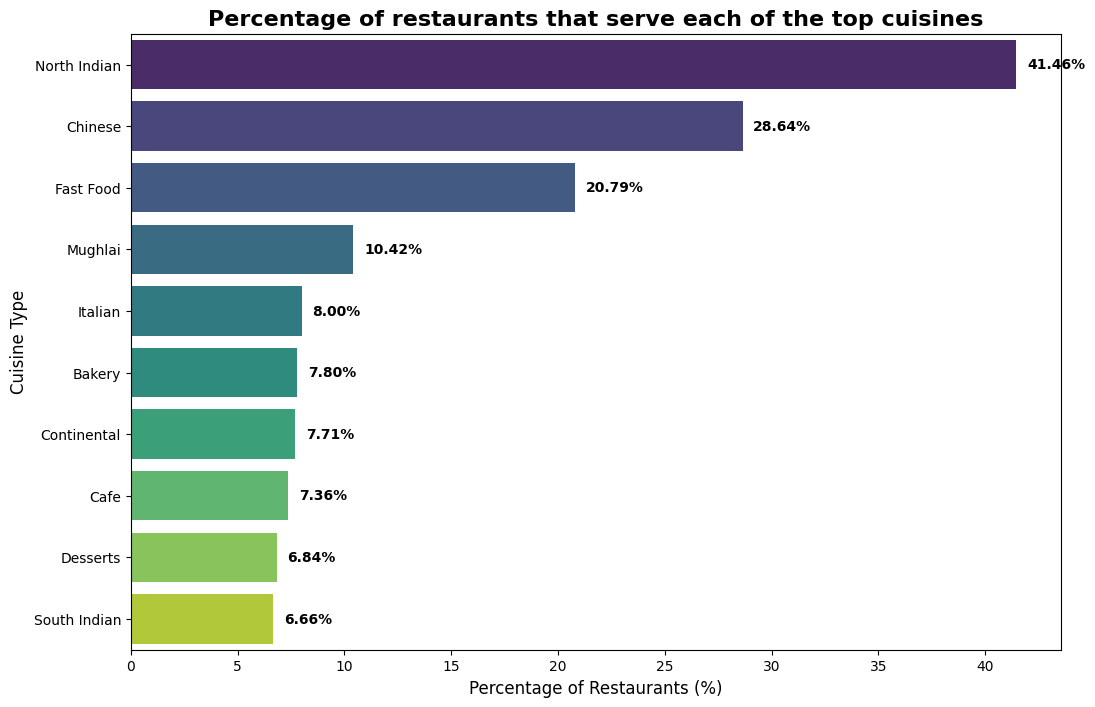

In [ ]:
plt.figure(figsize=(12, 8))
# Creating a horizontal bar chart for better readability of cuisine names
ax = sns.barplot(data=top_10_df, x='Percentage', y='Cuisine', palette='viridis')

# Adding percentage labels on the bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{top_10_df.Percentage.iloc[i]:.2f}%',
                (p.get_width() + 0.5, p.get_y() + p.get_height() / 2),
                va='center', fontweight='bold')

plt.title('Percentage of restaurants that serve each of the top cuisines', fontsize=16, fontweight='bold')
plt.xlabel('Percentage of Restaurants (%)', fontsize=12)
plt.ylabel('Cuisine Type', fontsize=12)
plt.show()

#**TASK 2 (Task: City Analysis)**

**1.Identify the city with the highest number of restaurants in the dataset.**

In [ ]:
df['City']

,City
0,Makati City
1,Makati City
2,Mandaluyong City
3,Mandaluyong City
4,Mandaluyong City
...,...
9546,stanbul
9547,stanbul
9548,stanbul
9549,stanbul


Count the number of restaurants per city

In [ ]:
city_counts = df['City'].value_counts()

In [ ]:
city_counts

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
...,...
Lakes Entrance,1
Mohali,1
Panchkula,1


Identify the top city

In [ ]:
top_city_name = city_counts.index[0]
print(top_city_name)

New Delhi


In [ ]:
top_city_val = city_counts.values[0]
print(top_city_val)

5473


In [ ]:
print(f"The city with the highest number of restaurants is: {top_city_name} ({top_city_val} restaurants)")

The city with the highest number of restaurants is: New Delhi (5473 restaurants)


**For Visualization**

In [ ]:
# Prepare data for the Top 10 cities visualization
top_10_cities = city_counts.head(10)

/tmp/ipykernel_595/473990356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='Reds_r')


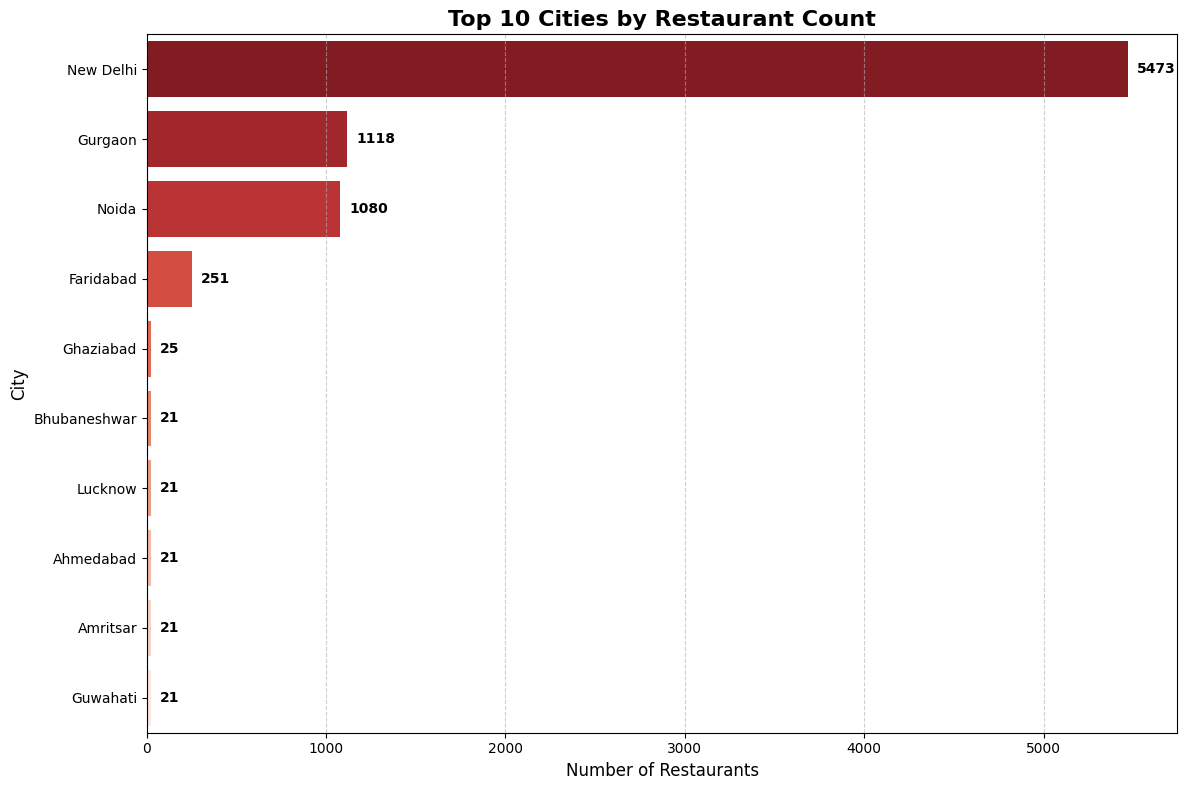

In [ ]:
# Visualization: Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='Reds_r')

# Adding the exact count labels on the bars
for i, v in enumerate(top_10_cities.values):
    plt.text(v + 50, i, str(v), va='center', fontweight='bold')

plt.title('Top 10 Cities by Restaurant Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**2. Calculate the average rating for restaurants in each city**

In [ ]:
df['City']

,City
0,Makati City
1,Makati City
2,Mandaluyong City
3,Mandaluyong City
4,Mandaluyong City
...,...
9546,stanbul
9547,stanbul
9548,stanbul
9549,stanbul


Group by City and calculate the mean of Aggregate rating. We sort by rating to find the highest performing cities

In [ ]:
city_avg_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).reset_index()
city_avg_rating.columns = ['City', 'Average Rating']
print(city_avg_rating)

                 City  Average Rating
0          Inner City        4.900000
1         Quezon City        4.800000
2         Makati City        4.650000
3          Pasig City        4.633333
4    Mandaluyong City        4.625000
..                ...             ...
136         New Delhi        2.438845
137         Montville        2.400000
138         Mc Millan        2.400000
139             Noida        2.036204
140         Faridabad        1.866932

[141 rows x 2 columns]


In [ ]:
#Identify average rating for restaurants in each city
top_rated_cities = city_avg_rating
print(top_rated_cities)


                 City  Average Rating
0          Inner City        4.900000
1         Quezon City        4.800000
2         Makati City        4.650000
3          Pasig City        4.633333
4    Mandaluyong City        4.625000
..                ...             ...
136         New Delhi        2.438845
137         Montville        2.400000
138         Mc Millan        2.400000
139             Noida        2.036204
140         Faridabad        1.866932

[141 rows x 2 columns]


**3. Determine the city with the highest average rating.**

In [ ]:
df['City']

,City
0,Makati City
1,Makati City
2,Mandaluyong City
3,Mandaluyong City
4,Mandaluyong City
...,...
9546,stanbul
9547,stanbul
9548,stanbul
9549,stanbul


In [ ]:
#. Group by city and calculate the average rating
city_avg_rating = df.groupby('City')['Aggregate rating'].mean().reset_index()
print(city_avg_rating)

                City  Aggregate rating
0          Abu Dhabi          4.300000
1               Agra          3.965000
2          Ahmedabad          4.161905
3             Albany          3.555000
4          Allahabad          3.395000
..               ...               ...
136          Weirton          3.900000
137  Wellington City          4.250000
138   Winchester Bay          3.200000
139          Yorkton          3.300000
140          stanbul          4.292857

[141 rows x 2 columns]


In [ ]:
#. Identify the city with the maximum average rating
highest_rated_city = city_avg_rating.sort_values(by='Aggregate rating', ascending=False).iloc[0]
print(highest_rated_city)

City                Inner City
Aggregate rating           4.9
Name: 56, dtype: object


In [ ]:
print(f"City with the highest average rating: {highest_rated_city['City']}")
print(f"Average Rating: {highest_rated_city['Aggregate rating']:.2f}")

City with the highest average rating: Inner City
Average Rating: 4.90


#**Visualization**

/tmp/ipykernel_595/1396785669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_cities, x='Aggregate rating', y='City', palette='flare')


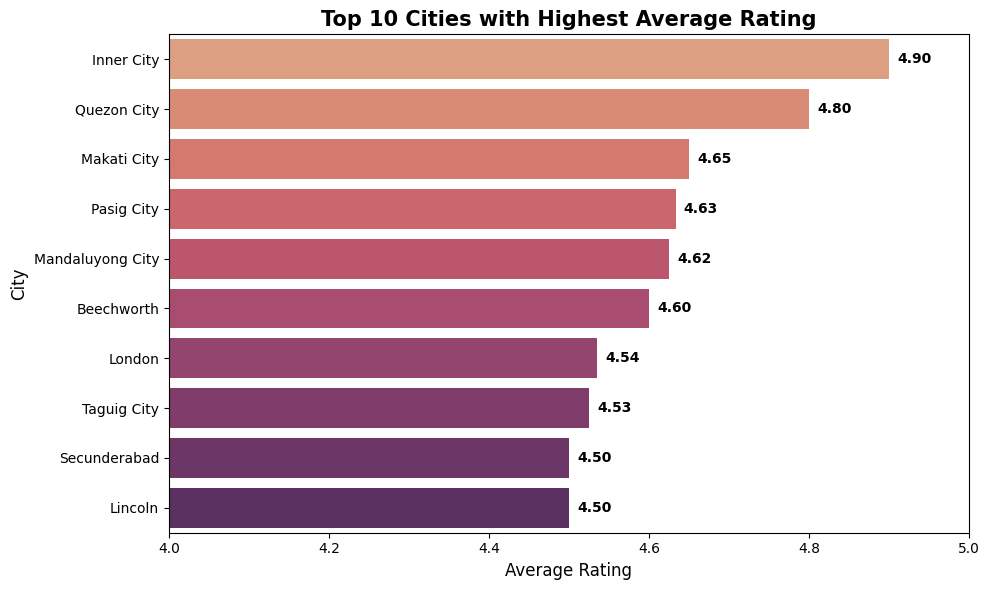

In [ ]:
top_10_cities = city_avg_rating.sort_values(by='Aggregate rating', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_cities, x='Aggregate rating', y='City', palette='flare')

# Highlighting the value on each bar
for i, v in enumerate(top_10_cities['Aggregate rating']):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontweight='bold')

plt.title('Top 10 Cities with Highest Average Rating', fontsize=15, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xlim(4.0, 5.0)
plt.tight_layout()
plt.show()

# **TASK 3 (Task: Price Range Distribution)**

**1. Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants.**

In [ ]:
df['Price range']

,Price range
0,3
1,3
2,4
3,4
4,4
...,...
9546,3
9547,3
9548,4
9549,4


In [ ]:
# Count the occurrences of each price range
price_range_counts = df['Price range'].value_counts().sort_index()
print(price_range_counts)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


# **Visualization: Bar Chart**

/tmp/ipykernel_595/4203668959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_range_counts.index, y=price_range_counts.values, palette='viridis')


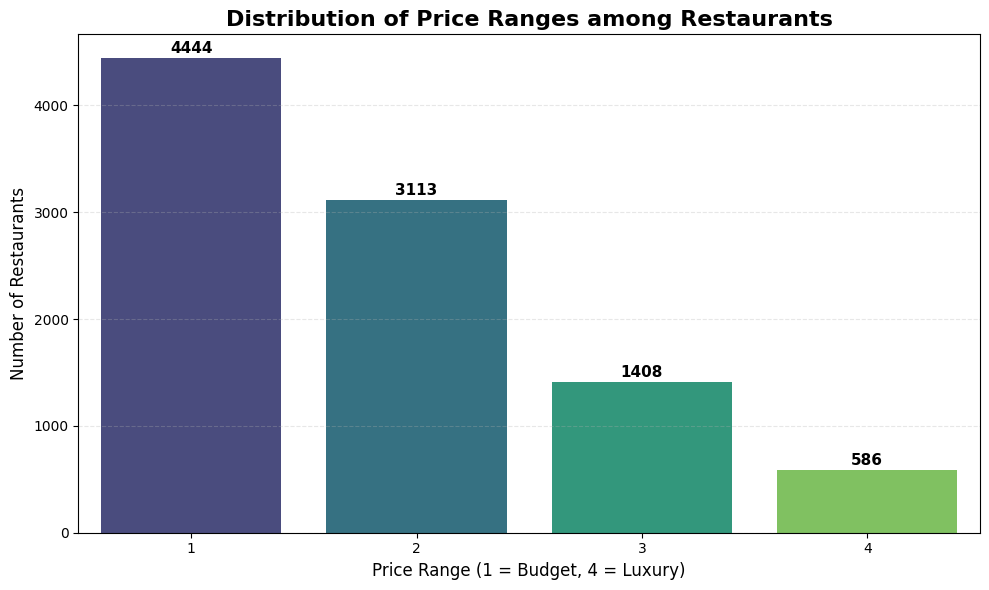

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=price_range_counts.index, y=price_range_counts.values, palette='viridis')

# Adding the exact count labels on top of the bars
for i, v in enumerate(price_range_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=11)

plt.title('Distribution of Price Ranges among Restaurants', fontsize=16, fontweight='bold')
plt.xlabel('Price Range (1 = Budget, 4 = Luxury)', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**2.Calculate the percentage of restaurants in each price range category**

In [ ]:
#. Calculate the total number of restaurants
total_restaurants = len(df)
print(total_restaurants)

9551


In [ ]:
#. Count occurrences and calculate percentages
price_range_counts = df['Price range'].value_counts().sort_index()
print(price_range_counts)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [ ]:
price_range_pct = (price_range_counts / total_restaurants) * 100
print(price_range_pct)

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


In [ ]:
#. Print text results for the report
print("--- Percentage of Restaurants per Price Range ---")
for pr, pct in price_range_pct.items():
    print(f"Price Range {pr}: {pct:.2f}%")

--- Percentage of Restaurants per Price Range ---
Price Range 1: 46.53%
Price Range 2: 32.59%
Price Range 3: 14.74%
Price Range 4: 6.14%


# **Visualization: Pie Chart**

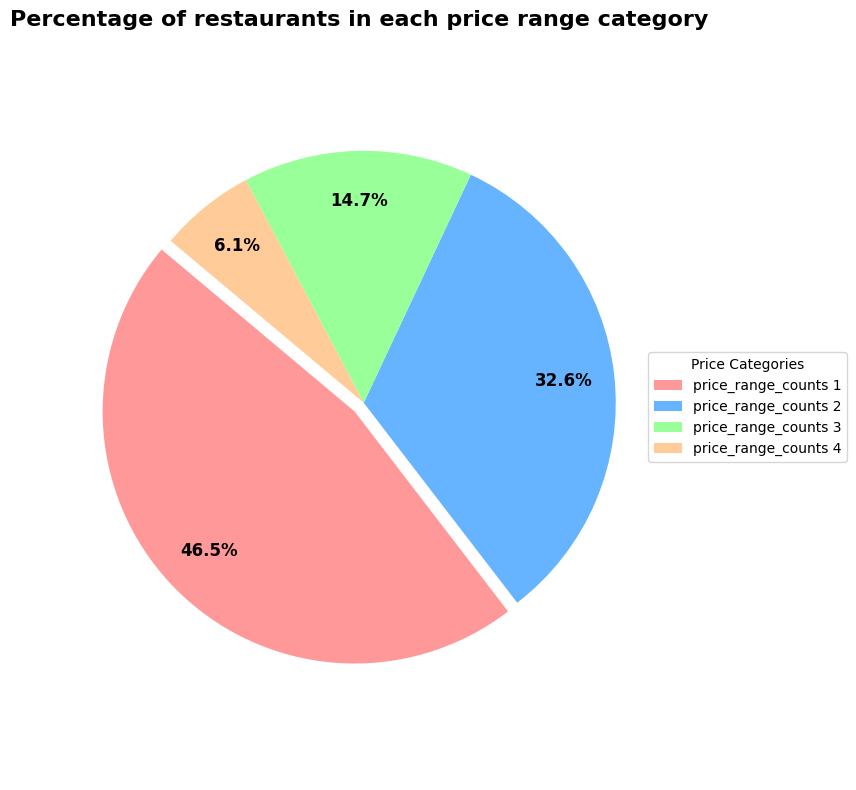

In [ ]:
plt.figure(figsize=(8, 8))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

wedges, texts, autotexts = plt.pie(
    price_range_pct,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0, 0, 0),
    pctdistance=0.80,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
plt.legend(
    wedges,
    [f"price_range_counts {i}" for i in price_range_counts.index],
    title="Price Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Percentage of restaurants in each price range category', fontsize=16, fontweight='bold')
plt.axis('equal')

plt.tight_layout()
plt.show()

# **TASK 4 (Task: Online Delivery)**

**1. Determine the percentage of restaurants that offer online delivery**

In [ ]:
#. Calculate counts and percentages
total_restaurants = len(df)
online_delivery_counts = df['Has Online delivery'].value_counts()
online_delivery_pct = (online_delivery_counts / total_restaurants) * 100

In [ ]:
# Print the text result
print(f"Percentage of restaurants that offer online delivery: {online_delivery_pct['Yes']:.2f}%")

Percentage of restaurants that offer online delivery: 25.66%


# **Visualization: Pie Chart**

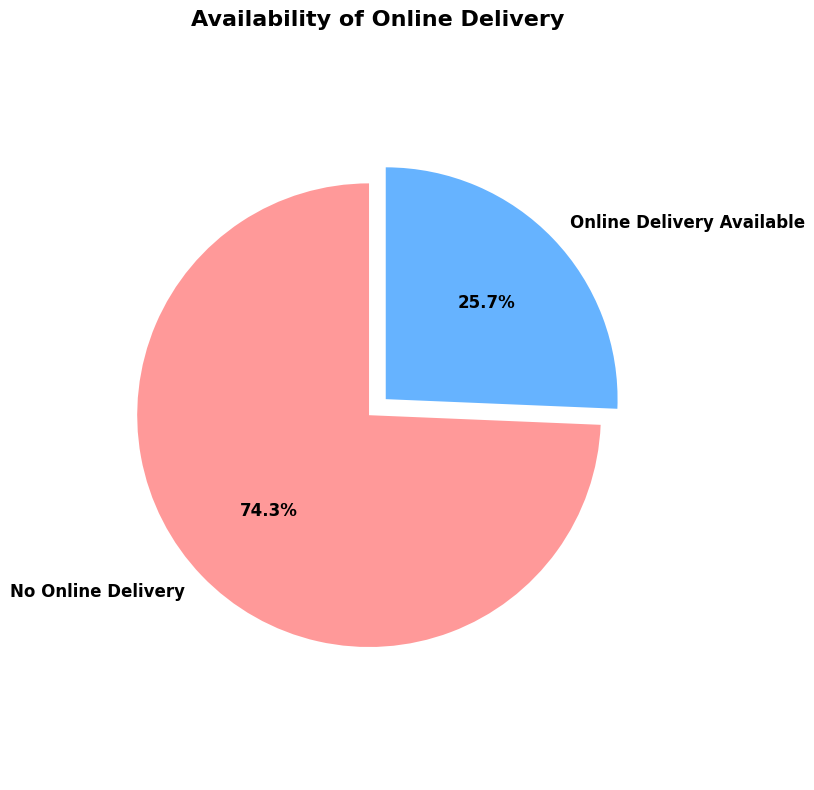

In [ ]:
plt.figure(figsize=(8, 8))
colors = ['#ff9999','#66b3ff']
labels = ['No Online Delivery', 'Online Delivery Available']

plt.pie(
    online_delivery_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.1), # Highlight the "Yes" category
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Availability of Online Delivery', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

**2.Compare the average ratings of restaurants with and without online delivery**


In [ ]:
#. Group by 'Has Online delivery' and calculate the mean of 'Aggregate rating'
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean().reset_index()

In [ ]:
print(avg_rating_delivery)

  Has Online delivery  Aggregate rating
0                  No          2.465296
1                 Yes          3.248837


In [ ]:
#. Print text results
print("Average Ratings:")
for index, row in avg_rating_delivery.iterrows():
    print(f"Online Delivery: {row['Has Online delivery']} | Average Rating: {row['Aggregate rating']:.2f}")

Average Ratings:
Online Delivery: No | Average Rating: 2.47
Online Delivery: Yes | Average Rating: 3.25


# **Visualization: Bar Chart**

/tmp/ipykernel_595/2051173389.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_rating_delivery, x='Has Online delivery', y='Aggregate rating', palette='Set2')


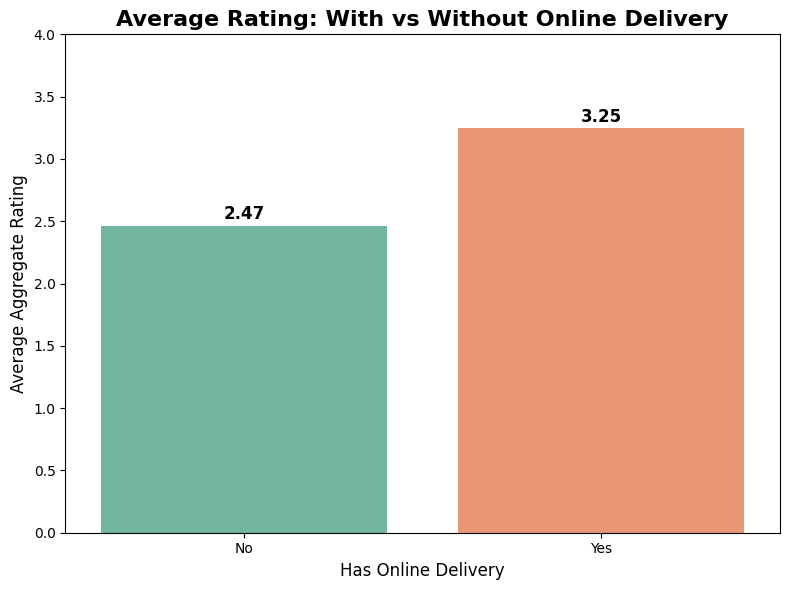

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_rating_delivery, x='Has Online delivery', y='Aggregate rating', palette='Set2')

for index, row in avg_rating_delivery.iterrows():
    plt.text(index, row['Aggregate rating'] + 0.05, f"{row['Aggregate rating']:.2f}",
             ha='center', fontweight='bold', fontsize=12)

plt.title('Average Rating: With vs Without Online Delivery', fontsize=16, fontweight='bold')
plt.xlabel('Has Online Delivery', fontsize=12)
plt.ylabel('Average Aggregate Rating', fontsize=12)
plt.ylim(0, 4)

plt.tight_layout()
plt.show()